# Phase 2 — Data Cleaning & Preprocessing
**Project:** E-Commerce Customer Behavior ML

| Step | Task |
|---|---|
| 0 | Setup & load raw data |
| 1 | Parse & engineer datetime columns |
| 2 | Outlier detection & treatment |
| 3 | Categorical encoding |
| 4 | Create derived / flag features |
| 5 | Final validation |
| 6 | Save cleaned datasets to `data/processed/` |


## Step 0 — Setup & Load Raw Data

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Dynamic paths (works on any OS, any machine) ──────────────────────────────
_cwd         = Path().resolve()
_candidates  = [_cwd / 'data' / 'raw', _cwd.parent / 'data' / 'raw']
RAW_DIR      = next((p for p in _candidates if p.exists()), None)

if RAW_DIR is None:
    raise FileNotFoundError(
        f"data/raw/ not found. Run: python src/data/generate_data.py"
    )

PROJECT_ROOT  = RAW_DIR.parent.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'reports' / 'figures'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Set2')

# ── Load all raw tables ───────────────────────────────────────────────────────
raw = {f.stem: pd.read_csv(f) for f in sorted(RAW_DIR.glob('*.csv'))}

print("Raw tables loaded:")
for name, df in raw.items():
    print(f"  {name:<20} {len(df):>8,} rows  |  {df.shape[1]} cols")

Raw tables loaded:
  browse_events          89,016 rows  |  7 cols
  order_items            23,958 rows  |  5 cols
  orders                  8,000 rows  |  7 cols
  products                  500 rows  |  9 cols
  sessions               20,000 rows  |  9 cols
  users                   5,000 rows  |  10 cols


## Step 1 — Parse & Engineer Datetime Columns
Datetime columns arrive as plain strings. We convert them and extract
useful time-based features that will become predictors in Phase 5.


In [2]:
# ── Sessions: parse timestamps, extract time features ─────────────────────────
sessions = raw['sessions'].copy()

for col in ['session_start', 'session_end']:
    if col in sessions.columns:
        sessions[col] = pd.to_datetime(sessions[col])

sessions['hour_of_day']    = sessions['session_start'].dt.hour
sessions['day_of_week']    = sessions['session_start'].dt.dayofweek   # 0=Mon
sessions['day_name']       = sessions['session_start'].dt.day_name()
sessions['is_weekend']     = sessions['day_of_week'].isin([5, 6]).astype(int)
sessions['month']          = sessions['session_start'].dt.month
sessions['week_of_year']   = sessions['session_start'].dt.isocalendar().week.astype(int)

# Session time-of-day bucket (business logic)
def time_bucket(hour):
    if   6  <= hour < 12: return 'morning'
    elif 12 <= hour < 17: return 'afternoon'
    elif 17 <= hour < 21: return 'evening'
    else:                  return 'night'

sessions['time_bucket'] = sessions['hour_of_day'].apply(time_bucket)

print("Sessions — new datetime columns:")
print(sessions[['session_id','session_start','hour_of_day','day_name',
                'is_weekend','time_bucket','month']].head(5).to_string())

Sessions — new datetime columns:
  session_id       session_start  hour_of_day  day_name  is_weekend time_bucket  month
0    S000001 2024-12-24 04:32:10            4   Tuesday           0       night     12
1    S000002 2024-09-13 18:37:09           18    Friday           0     evening      9
2    S000003 2025-04-05 13:04:43           13  Saturday           1   afternoon      4
3    S000004 2025-05-09 02:05:29            2    Friday           0       night      5
4    S000005 2024-12-17 21:41:30           21   Tuesday           0       night     12


In [3]:
# ── Orders: parse order_date ─────────────────────────────────────────────────
orders = raw['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month']       = orders['order_date'].dt.month
orders['order_day_of_week'] = orders['order_date'].dt.dayofweek
orders['order_is_weekend']  = orders['order_day_of_week'].isin([5, 6]).astype(int)
orders['order_hour']        = orders['order_date'].dt.hour

print("Orders — new datetime columns:")
print(orders[['order_id','order_date','order_month',
              'order_day_of_week','order_is_weekend']].head(5).to_string())

Orders — new datetime columns:
  order_id          order_date  order_month  order_day_of_week  order_is_weekend
0  O000001 2024-08-01 05:15:31            8                  3                 0
1  O000002 2025-04-12 05:41:13            4                  5                 1
2  O000003 2024-12-11 09:58:12           12                  2                 0
3  O000004 2025-01-06 17:29:08            1                  0                 0
4  O000005 2024-10-21 19:21:56           10                  0                 0


In [4]:
# ── Users: parse signup_date → account_age_days ──────────────────────────────
users = raw['users'].copy()
users['signup_date']      = pd.to_datetime(users['signup_date'])
reference_date            = orders['order_date'].max()          # latest order date
users['account_age_days'] = (reference_date - users['signup_date']).dt.days.clip(lower=0)

print("Users — account age stats (days):")
print(users['account_age_days'].describe().round(1).to_string())

Users — account age stats (days):
count   5000.000
mean     339.100
std      206.800
min        0.000
25%      162.000
50%      333.500
75%      503.000
max      978.000


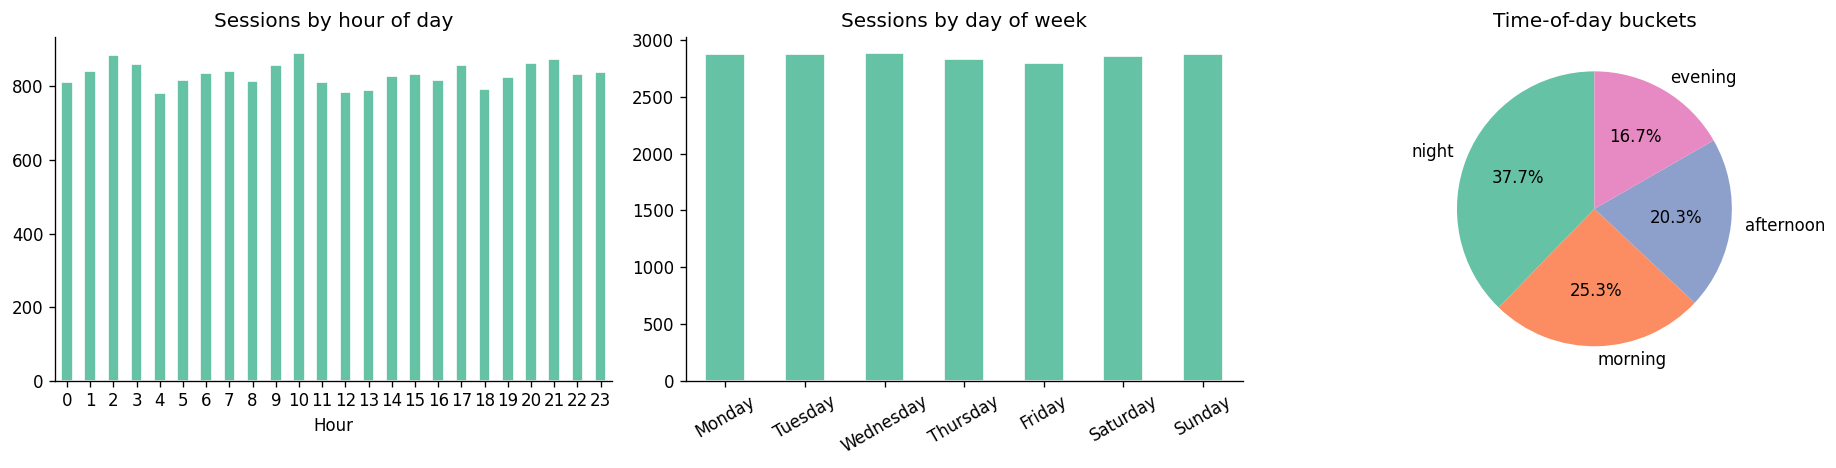

Chart saved → C:\Users\ATUL\Desktop\BIT BOY\ECOMMERCE_CUSTOMER_BEHAVIOR\reports\figures\02_datetime_patterns.png


In [5]:
# Visualise session activity patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sessions['hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Sessions by hour of day')
axes[0].set_xlabel('Hour')
axes[0].tick_params(axis='x', rotation=0)

sessions['day_name'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Sessions by day of week')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

sessions['time_bucket'].value_counts().plot(
    kind='pie', ax=axes[2], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Time-of-day buckets')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_datetime_patterns.png', bbox_inches='tight')
plt.show()
print(f"Chart saved → {FIGURES_DIR / '02_datetime_patterns.png'}")

## Step 2 — Outlier Detection & Treatment
We use the **IQR method** (no magic numbers) to detect outliers.
Treatment strategy:
- `duration_secs` → **clip** at 95th percentile (preserve scale)
- `total_amount`  → **log1p transform** (compress extreme values)
- `pages_visited` → **clip** at 99th percentile
- `time_spent_secs` (browse events) → **clip** at 95th percentile


In [6]:
def iqr_bounds(series, factor=1.5):
    """Return lower and upper IQR-based bounds for outlier detection."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

# Report outliers before treatment
check_cols = {
    'sessions':      ['duration_secs', 'pages_visited'],
    'orders':        ['total_amount'],
    'browse_events': ['time_spent_secs'],
}

print(f"{'Table.Column':<35} {'Min':>8} {'Max':>10} {'IQR Lo':>10} {'IQR Hi':>10} {'Outliers':>10}")
print('-' * 90)
for tname, cols in check_cols.items():
    df = raw[tname]
    for col in cols:
        if col not in df.columns: continue
        lo, hi   = iqr_bounds(df[col])
        n_out    = ((df[col] < lo) | (df[col] > hi)).sum()
        print(f"{tname+'.'+col:<35} {df[col].min():>8.1f} {df[col].max():>10.1f}"
              f" {lo:>10.1f} {hi:>10.1f} {n_out:>10,}")

Table.Column                             Min        Max     IQR Lo     IQR Hi   Outliers
------------------------------------------------------------------------------------------
sessions.duration_secs                  10.0     7044.0     -827.0     1837.0        922
sessions.pages_visited                   1.0       43.0       -6.5       13.5      1,161
orders.total_amount                      5.0     1499.9     -755.9     2249.7          0
browse_events.time_spent_secs            2.0      300.0     -149.0      451.0          0


In [7]:
# ── Apply treatments ──────────────────────────────────────────────────────────

# sessions — clip duration & pages
p95_dur   = sessions['duration_secs'].quantile(0.95)
p99_pages = sessions['pages_visited'].quantile(0.99)
sessions['duration_secs_clean'] = sessions['duration_secs'].clip(upper=p95_dur)
sessions['pages_visited_clean'] = sessions['pages_visited'].clip(upper=p99_pages)
print(f"duration_secs clipped at 95th pct : {p95_dur:.0f}s")
print(f"pages_visited clipped at 99th pct : {p99_pages:.0f} pages")

# orders — clip then log1p transform
p95_amt = orders['total_amount'].quantile(0.95)
orders['total_amount_clipped'] = orders['total_amount'].clip(upper=p95_amt)
orders['log_total_amount']     = np.log1p(orders['total_amount_clipped'])
print(f"total_amount  clipped at 95th pct : ${p95_amt:.2f}")
print(f"log1p transform applied → log_total_amount")

# browse_events
browse_events = raw['browse_events'].copy()
p95_time = browse_events['time_spent_secs'].quantile(0.95)
browse_events['time_spent_secs_clean'] = browse_events['time_spent_secs'].clip(upper=p95_time)
print(f"time_spent_secs clipped at 95th pct : {p95_time:.0f}s")

duration_secs clipped at 95th pct : 1786s
pages_visited clipped at 99th pct : 23 pages
total_amount  clipped at 95th pct : $1427.43
log1p transform applied → log_total_amount
time_spent_secs clipped at 95th pct : 285s


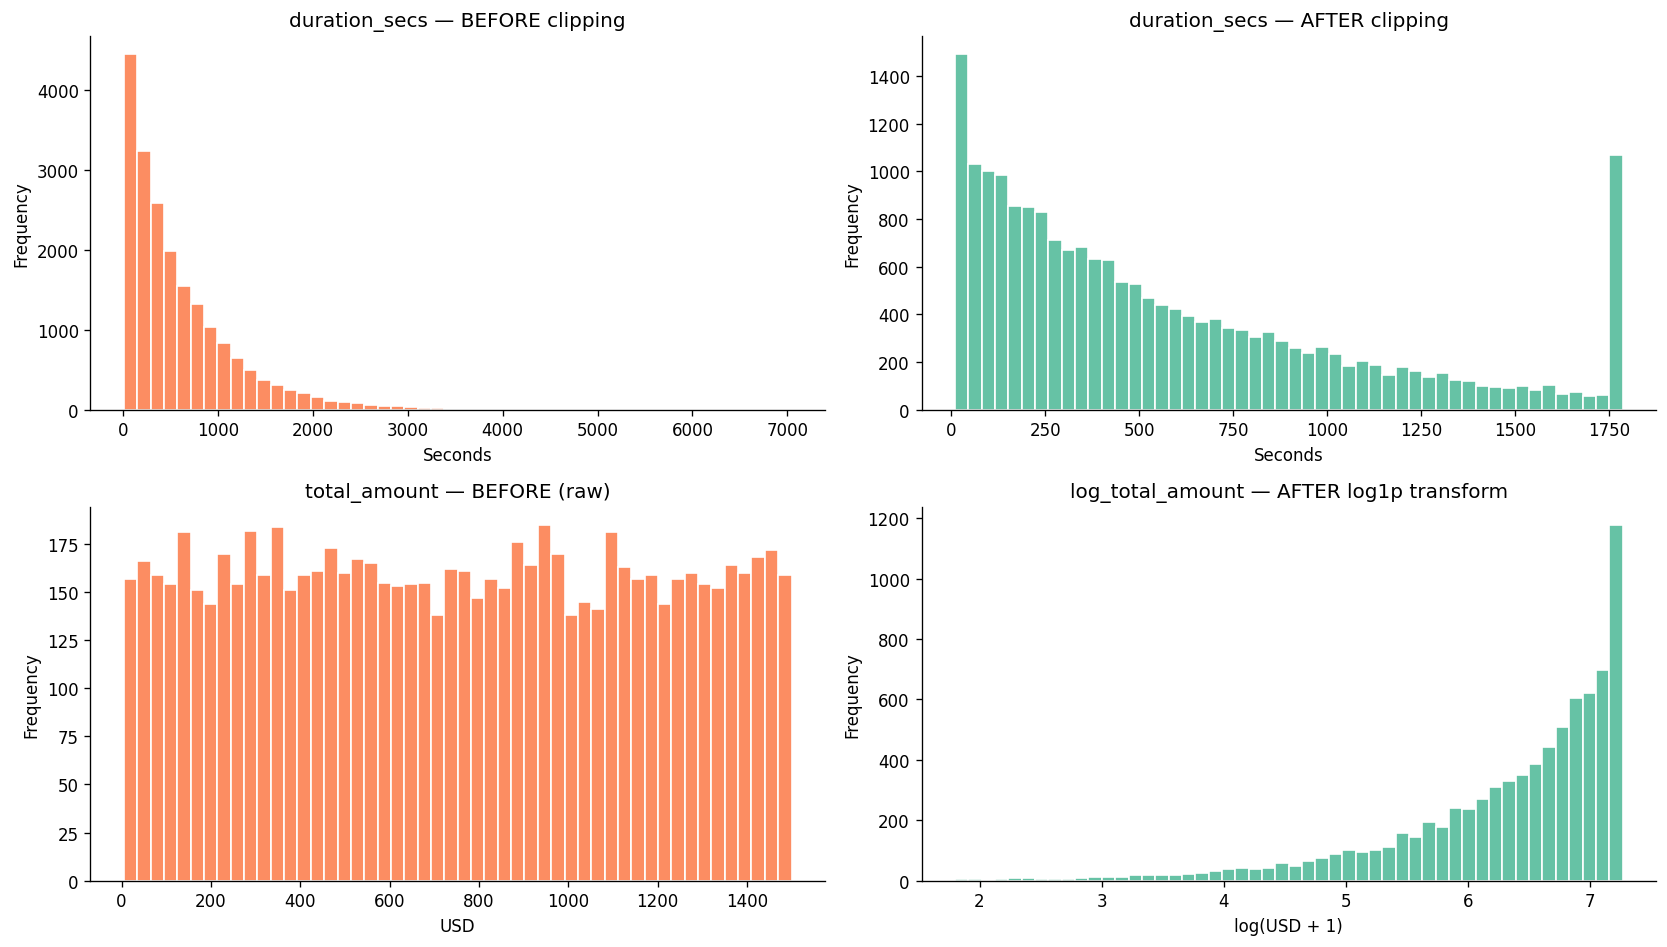

Chart saved → reports/figures/02_outlier_treatment.png


In [8]:
# Before / After visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Duration before
raw['sessions']['duration_secs'].plot(
    kind='hist', bins=50, ax=axes[0][0], edgecolor='white', color='#fc8d62')
axes[0][0].set_title('duration_secs — BEFORE clipping')
axes[0][0].set_xlabel('Seconds')

# Duration after
sessions['duration_secs_clean'].plot(
    kind='hist', bins=50, ax=axes[0][1], edgecolor='white', color='#66c2a5')
axes[0][1].set_title('duration_secs — AFTER clipping')
axes[0][1].set_xlabel('Seconds')

# Order amount before
raw['orders']['total_amount'].plot(
    kind='hist', bins=50, ax=axes[1][0], edgecolor='white', color='#fc8d62')
axes[1][0].set_title('total_amount — BEFORE (raw)')
axes[1][0].set_xlabel('USD')

# Order amount after log transform
orders['log_total_amount'].plot(
    kind='hist', bins=50, ax=axes[1][1], edgecolor='white', color='#66c2a5')
axes[1][1].set_title('log_total_amount — AFTER log1p transform')
axes[1][1].set_xlabel('log(USD + 1)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_outlier_treatment.png', bbox_inches='tight')
plt.show()
print("Chart saved → reports/figures/02_outlier_treatment.png")

## Step 3 — Categorical Encoding
| Column | Strategy | Reason |
|---|---|---|
| `membership` | Ordinal (0-3) | Has natural order: free < silver < gold < platinum |
| `gender` | One-hot | No natural order |
| `device_type` | One-hot | No natural order |
| `referral_source` | One-hot | No natural order |
| `order status` | Ordinal | Has natural order |
| `bounced` | Already bool → int | Binary |


In [9]:
# ── Ordinal encoding — membership ─────────────────────────────────────────────
membership_order = {'free': 0, 'silver': 1, 'gold': 2, 'platinum': 3}
users['membership_encoded'] = users['membership'].map(membership_order)

print("Membership encoding:")
print(users[['membership', 'membership_encoded']].value_counts().sort_index().to_string())

Membership encoding:
membership  membership_encoded
free        0                     2690
gold        2                      735
platinum    3                      276
silver      1                     1299


In [10]:
# ── One-hot encoding — gender, device_type ────────────────────────────────────
users = pd.get_dummies(users, columns=['gender', 'device_type'], 
                       prefix=['gender', 'device'], drop_first=False, dtype=int)

new_cols = [c for c in users.columns if c.startswith(('gender_', 'device_'))]
print(f"New one-hot columns added to users ({len(new_cols)}): {new_cols}")
print(users[new_cols].head(3).to_string())

New one-hot columns added to users (6): ['gender_Female', 'gender_Male', 'gender_Other', 'device_desktop', 'device_mobile', 'device_tablet']
   gender_Female  gender_Male  gender_Other  device_desktop  device_mobile  device_tablet
0              0            1             0               0              1              0
1              0            0             1               0              1              0
2              1            0             0               0              0              1


In [11]:
# ── One-hot encoding — referral_source in sessions ────────────────────────────
sessions = pd.get_dummies(sessions, columns=['referral_source'],
                          prefix='ref', drop_first=False, dtype=int)
ref_cols = [c for c in sessions.columns if c.startswith('ref_')]
print(f"Referral source columns ({len(ref_cols)}): {ref_cols}")

Referral source columns (6): ['ref_direct', 'ref_email', 'ref_organic_search', 'ref_paid_search', 'ref_referral', 'ref_social_media']


In [12]:
# ── Ordinal encoding — order status ──────────────────────────────────────────
status_order = {'processing': 0, 'shipped': 1, 'delivered': 2,
                'returned': -1, 'cancelled': -2}
orders['status_encoded'] = orders['status'].map(status_order)

print("Order status encoding:")
print(orders[['status', 'status_encoded']].value_counts().sort_index().to_string())

Order status encoding:
status      status_encoded
cancelled   -2                 425
delivered    2                5154
processing   0                 869
returned    -1                 350
shipped      1                1202


In [13]:
# ── Encode bounced (bool → int) ───────────────────────────────────────────────
sessions['bounced'] = sessions['bounced'].astype(int)
print("bounced encoded: 0=No, 1=Yes")
print(sessions['bounced'].value_counts().to_string())

bounced encoded: 0=No, 1=Yes
bounced
0    12442
1     7558


## Step 4 — Derived & Flag Features
Creating new columns that capture business logic the raw data doesn't explicitly encode.


In [14]:
# ── Users: age group bins ─────────────────────────────────────────────────────
age_bins   = [0, 25, 35, 50, 100]
age_labels = ['18-25', '26-35', '36-50', '50+']
users['age_group'] = pd.cut(users['age'], bins=age_bins, 
                             labels=age_labels, right=True)

print("Age group distribution:")
print(users['age_group'].value_counts().sort_index().to_string())

Age group distribution:
age_group
18-25    1249
26-35    1884
36-50    1683
50+       184


In [15]:
# ── Users: is_premium flag (gold + platinum) ──────────────────────────────────
users['is_premium'] = users['membership'].isin(['gold', 'platinum']).astype(int)
print(f"\nPremium users : {users['is_premium'].sum():,} ({100*users['is_premium'].mean():.1f}%)")
print(f"Free/silver   : {(users['is_premium']==0).sum():,} ({100*(1-users['is_premium'].mean()):.1f}%)")


Premium users : 1,011 (20.2%)
Free/silver   : 3,989 (79.8%)


In [16]:
# ── Sessions: engagement score (composite) ────────────────────────────────────
# Normalize components to 0-1 range before combining
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

sessions['engagement_score'] = (
    0.4 * minmax(sessions['pages_visited_clean']) +
    0.4 * minmax(sessions['duration_secs_clean']) +
    0.2 * (1 - sessions['bounced'])               # non-bounce = engaged
).round(4)

print("Engagement score distribution:")
print(sessions['engagement_score'].describe().round(3).to_string())

Engagement score distribution:
count   20000.000
mean        0.316
std         0.170
min         0.000
25%         0.207
50%         0.302
75%         0.418
max         1.000


In [17]:
# ── Orders: high value order flag ────────────────────────────────────────────
high_val_threshold            = orders['total_amount'].quantile(0.75)
orders['is_high_value_order'] = (orders['total_amount'] >= high_val_threshold).astype(int)
print(f"High-value order threshold (75th pct) : ${high_val_threshold:.2f}")
print(f"High-value orders : {orders['is_high_value_order'].sum():,} / {len(orders):,}")

High-value order threshold (75th pct) : $1122.55
High-value orders : 2,000 / 8,000


In [18]:
# ── Browse events: cart interaction flag ─────────────────────────────────────
browse_events['added_to_cart'] = (browse_events['event_type'] == 'add_to_cart').astype(int)
browse_events['wishlisted']    = (browse_events['event_type'] == 'add_to_wishlist').astype(int)

# User-level cart signals (aggregate per user)
user_cart_signals = browse_events.groupby('user_id').agg(
    total_events        = ('event_id',    'count'),
    total_cart_adds     = ('added_to_cart','sum'),
    total_wishlists     = ('wishlisted',  'sum'),
    unique_products_browsed = ('product_id', 'nunique'),
    avg_time_per_event  = ('time_spent_secs_clean', 'mean'),
).reset_index()
user_cart_signals['cart_rate'] = (
    user_cart_signals['total_cart_adds'] / 
    user_cart_signals['total_events'].replace(0, np.nan)
).fillna(0).round(4)

print("User-level cart signals (sample):")
print(user_cart_signals.head(5).to_string())

User-level cart signals (sample):
  user_id  total_events  total_cart_adds  total_wishlists  unique_products_browsed  avg_time_per_event  cart_rate
0  U00001            23                4                1                       21             177.652      0.174
1  U00002             9                1                0                        9             160.556      0.111
2  U00003            45                7                2                       38             147.378      0.156
3  U00004            22                3                1                       20             136.500      0.136
4  U00006            12                0                2                       10             146.667      0.000


## Step 5 — Final Validation

In [19]:
# Collect all cleaned tables
cleaned = {
    'users':         users,
    'products':      raw['products'].copy(),   # no cleaning needed for products
    'sessions':      sessions,
    'browse_events': browse_events,
    'orders':        orders,
    'order_items':   raw['order_items'].copy(),
    'user_cart_signals': user_cart_signals,
}

print(f"{'Table':<22} {'Rows':>8}   {'Cols':>5}   {'Nulls':>8}   Status")
print('-' * 58)
for name, df in cleaned.items():
    nulls  = df.isnull().sum().sum()
    status = '✓' if nulls == 0 else f'⚠️ {nulls} nulls'
    print(f"{name:<22} {len(df):>8,}   {df.shape[1]:>5}   {nulls:>8,}   {status}")

Table                      Rows    Cols      Nulls   Status
----------------------------------------------------------
users                     5,000      18          0   ✓
products                    500       9          0   ✓
sessions                 20,000      24          0   ✓
browse_events            89,016      10          0   ✓
orders                    8,000      15          0   ✓
order_items              23,958       5          0   ✓
user_cart_signals         4,465       7          0   ✓


In [20]:
# Summary of all new columns created in this phase
original_cols = {name: set(raw[name].columns) 
                 for name in ['users','sessions','orders','browse_events']}
new_cols_summary = {}
for name in ['users', 'sessions', 'orders', 'browse_events']:
    orig  = original_cols[name]
    curr  = set(cleaned[name].columns)
    added = curr - orig
    new_cols_summary[name] = sorted(added)

print("New columns created per table:")
for name, cols in new_cols_summary.items():
    print(f"  {name:<20}: {len(cols)} new  →  {cols}")

New columns created per table:
  users               : 10 new  →  ['account_age_days', 'age_group', 'device_desktop', 'device_mobile', 'device_tablet', 'gender_Female', 'gender_Male', 'gender_Other', 'is_premium', 'membership_encoded']
  sessions            : 16 new  →  ['day_name', 'day_of_week', 'duration_secs_clean', 'engagement_score', 'hour_of_day', 'is_weekend', 'month', 'pages_visited_clean', 'ref_direct', 'ref_email', 'ref_organic_search', 'ref_paid_search', 'ref_referral', 'ref_social_media', 'time_bucket', 'week_of_year']
  orders              : 8 new  →  ['is_high_value_order', 'log_total_amount', 'order_day_of_week', 'order_hour', 'order_is_weekend', 'order_month', 'status_encoded', 'total_amount_clipped']
  browse_events       : 3 new  →  ['added_to_cart', 'time_spent_secs_clean', 'wishlisted']


## Step 6 — Save Cleaned Datasets

In [21]:
# Save every cleaned table as parquet (faster & smaller than CSV)
# Fallback to CSV if pyarrow not installed

def save_df(df, name, out_dir):
    try:
        path = out_dir / f'{name}.parquet'
        df.to_parquet(path, index=False)
        fmt = 'parquet'
    except Exception:
        path = out_dir / f'{name}.csv'
        df.to_csv(path, index=False)
        fmt = 'csv'
    size_kb = path.stat().st_size / 1024
    return path, fmt, size_kb

print(f"Saving to: {PROCESSED_DIR}\n")
print(f"{'Table':<22} {'Format':>8}   {'Size':>10}   Path")
print('-' * 72)
for name, df in cleaned.items():
    path, fmt, size_kb = save_df(df, name, PROCESSED_DIR)
    print(f"{name:<22} {fmt:>8}   {size_kb:>7.1f} KB   {path.name}")

print("\nAll cleaned datasets saved ✓")

Saving to: C:\Users\ATUL\Desktop\BIT BOY\ECOMMERCE_CUSTOMER_BEHAVIOR\data\processed

Table                    Format         Size   Path
------------------------------------------------------------------------
users                   parquet     229.7 KB   users.parquet
products                parquet      20.1 KB   products.parquet
sessions                parquet     822.0 KB   sessions.parquet
browse_events           parquet    1273.7 KB   browse_events.parquet
orders                  parquet     350.0 KB   orders.parquet
order_items             parquet     295.8 KB   order_items.parquet
user_cart_signals       parquet      75.7 KB   user_cart_signals.parquet

All cleaned datasets saved ✓


## ✅ Phase 2 Complete

### What was done
| Task | Status |
|---|---|
| Datetime parsing (sessions, orders, users) | ✅ |
| Time feature extraction (hour, day, weekend, bucket) | ✅ |
| Outlier detection via IQR | ✅ |
| Clipping (duration, pages, time_spent) | ✅ |
| Log transform (total_amount) | ✅ |
| Ordinal encoding (membership, order status) | ✅ |
| One-hot encoding (gender, device, referral_source) | ✅ |
| Derived features (age_group, is_premium, engagement_score, cart_rate) | ✅ |
| Saved all cleaned tables to `data/processed/` | ✅ |

### ⏭️ Phase 3 — EDA
Open `03_eda.ipynb` — we'll analyse patterns in the cleaned data and generate
the key visualisations for the final report.
